# AdaBoost Method Demonstration In Python
#### Marketing Campaing Response Model
   

## Background: 
The large skin-clinic in the city of “ABZ” offers variety of products and services to customers. The marketing campaign was launched for introducing a new product.

The data shows response to the marketing campaign alongwith demographic and transaction data of customers.

The objective is to develop a predictive model which can be implemented for the next campaign

## Dataset Description :

| Column Name     | Description                                                                                  |
|-----------------|----------------------------------------------------------------------------------------------|
| Custid          | Unique Customer Identification Code                                                          |
| Age             | Age Group (1: <32 years, 2: 32–48 years, 3: >48 years)                                      |
| Gender          | Gender of Customer (1: Female, 2: Male)                                                     |
| MS              | Marital Status (1: Not Married, 2: Married)                                                 |
| Response        | Customer Campaign Response (1: Responded, 0: Not Responded)                                 |
| Pre_Month       | Purchase Status in Previous Month (1: Purchased, 2: No Purchase)                            |
| N_Products      | Number of Unique Products Purchased in One Year                                             |
| N_Service       | Number of Unique Services Purchased in One Year                                             |
| BillAmt_1       | Bill Amount (USD) for Purchase Transaction 1                                                |
| BillAmt_2       | Bill Amount (USD) for Purchase Transaction 2                                                |
| BillAmt_3       | Bill Amount (USD) for Purchase Transaction 3                                                |


###  Import Libraries

In [1]:
import pandas as pd  
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

###  Import Data

In [2]:
purchase_data1 = pd.read_csv('Purchase Data 1.csv')
purchase_data1.head()

,Custid,Pre_Month,N_Products,N_Service
0,1,2,15,24
1,2,1,22,29
2,3,1,17,21
3,4,2,18,22
4,5,1,31,35


In [3]:
purchase_data2 = pd.read_csv('Purchase Data 2.csv')
purchase_data2.head()

,Custid,BillAmt_1,BillAmt_2,BillAmt_3
0,1,12.34,13.26,5.88
1,2,18.65,2.12,5.13
2,3,7.22,3.31,3.65
3,4,6.15,2.95,2.34
4,5,20.64,2.67,4.07


In [4]:
response_data = pd.read_csv('Response Data.csv')
response_data.head()

,Custid,Age,Gender,MS,Response
0,1,2,1,2,1
1,2,2,2,1,0
2,3,1,1,2,0
3,4,2,1,1,0
4,5,2,2,1,0


In [5]:

#Merging above 3 datasets
masterdata=pd.merge(response_data,purchase_data1,how='left',on = 'Custid')
masterdata=pd.merge(masterdata,purchase_data2,how='left',on = 'Custid')
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [6]:
masterdata.dtypes

Custid          int64
Age             int64
Gender          int64
MS              int64
Response        int64
Pre_Month       int64
N_Products      int64
N_Service       int64
BillAmt_1     float64
BillAmt_2     float64
BillAmt_3     float64
dtype: object

### Variable Type Conversion: Integer → Category

In [7]:
masterdata['Age'] = masterdata['Age'].astype('category')
masterdata['Gender'] = masterdata['Gender'].astype('category')
masterdata['MS'] = masterdata['MS'].astype('category')
masterdata['Pre_Month'] = masterdata['Pre_Month'].astype('category')

In [8]:
masterdata.dtypes

Custid           int64
Age           category
Gender        category
MS            category
Response         int64
Pre_Month     category
N_Products       int64
N_Service        int64
BillAmt_1      float64
BillAmt_2      float64
BillAmt_3      float64
dtype: object

### Estimating Campaign Response Rate : Overall and by Segments


### a. Overall Campaign Response Rate

In [9]:
# Overall response rate
overall_response_rate = masterdata['Response'].mean() * 100
print(f"Overall Campaign Response Rate: {overall_response_rate:.2f}%")

Overall Campaign Response Rate: 13.23%


### Set up Target

In [10]:
X = masterdata.drop(columns=['Response','Custid'])
y = masterdata['Response']

In [11]:
X.head()

,Age,Gender,MS,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,2,1,2,2,15,24,12.34,13.26,5.88
1,2,2,1,1,22,29,18.65,2.12,5.13
2,1,1,2,1,17,21,7.22,3.31,3.65
3,2,1,1,2,18,22,6.15,2.95,2.34
4,2,2,1,1,31,35,20.64,2.67,4.07


### Create Dummies

In [12]:
X_enc = pd.get_dummies(X, drop_first=True) # explain this 
X_enc.head()

,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3,Age_2,Age_3,Gender_2,MS_2,Pre_Month_2
0,15,24,12.34,13.26,5.88,True,False,False,True,True
1,22,29,18.65,2.12,5.13,True,False,True,False,False
2,17,21,7.22,3.31,3.65,False,False,False,True,False
3,18,22,6.15,2.95,2.34,True,False,False,False,True
4,31,35,20.64,2.67,4.07,True,False,True,False,False


###  Split Data Into Train & Test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Build Model

AdaBoost does not build one large complex decision tree. Instead, it combines many very small and simple trees, **often just one split each**, where every new tree focuses on correcting the mistakes of the previous ones to improve overall accuracy.

**n_estimators = 100**

* Number of weak trees built sequentially.
* Practical range **50–500**.
* **Low** → underfitting, **Medium (50–200)** → good balance, **Very high** → overfitting & slower training.

**learning_rate = 1.0**

* Controls how much each tree influences the final model.
* Typical range **0.01–1**.
* **Low** → slower but better generalization, **High** → faster but risk of overfitting.
* **Inverse relation:** lower learning rate needs more estimators and vice-versa.


In [14]:
weak_learner = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator = weak_learner,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.1, n_estimators=200, random_state=42)

### Check Optimal Threshold

In [15]:

y_prob = ada.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
ix = np.argmax(j_scores)

best_threshold = thresholds[ix]
print("Optimal Threshold:", best_threshold)


Optimal Threshold: 0.4799698250942959


### Make Predictions

In [16]:
y_pred = (y_prob >= best_threshold).astype(int)

y_prob = ada.predict_proba(X_test)[:, 1]

### Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[912 301]
 [ 56 129]]


### Classification Report

In [18]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.75      0.84      1213
           1       0.30      0.70      0.42       185

    accuracy                           0.74      1398
   macro avg       0.62      0.72      0.63      1398
weighted avg       0.86      0.74      0.78      1398



###  ROC and AUC for Test Data

In [19]:

auc = roc_auc_score(y_test, y_prob)
print(f"Test AUC: {auc:.3f}")


Test AUC: 0.790


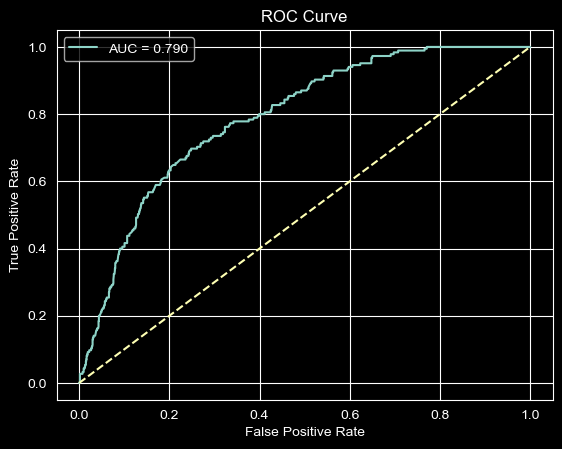

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_value = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.3f' % roc_auc_value)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Inference :
An ROC-AUC of 79% means the model has good ability to distinguish between the two classes.